# Detecting and Handling Outliers in Survey Data

**Author:** Mitadru Deb  
**Date:** February 2026

This notebook focuses on identifying and handling outliers in the developer survey dataset, particularly in compensation data and other key numeric variables.

## Importing Libraries

I'll start by importing the necessary libraries for data analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Loading and Exploring the Dataset

Let me load the dataset and take a look at its structure.

In [2]:
# Load the survey dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()[:10]}...")

# Show first few rows
df.head()

Dataset shape: (65437, 114)

Column names: ['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline']...


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [3]:
# Get more detailed information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB


## Distribution of Industry

I'll explore how respondents are distributed across different industries.

Top 15 Industries:
Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64


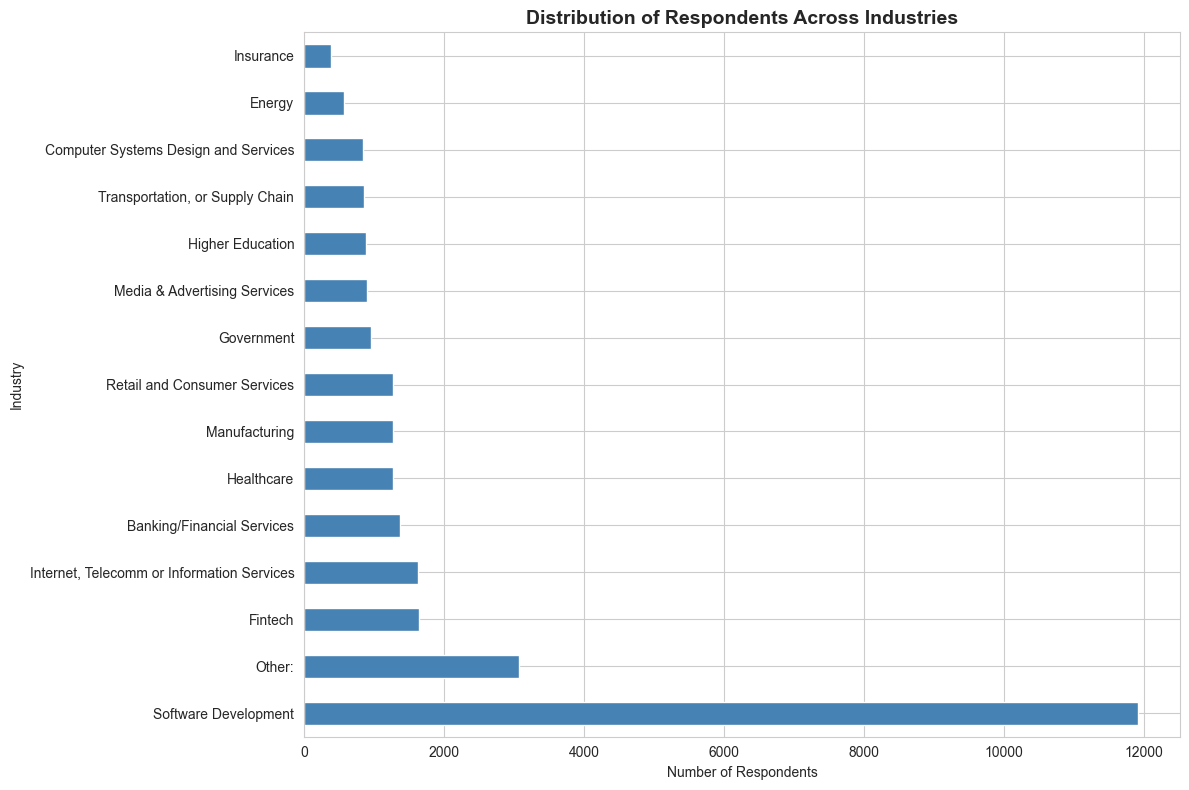

In [4]:
# Check if Industry column exists
if 'Industry' in df.columns:
    # Get industry distribution
    industry_counts = df['Industry'].value_counts().head(15)
    print("Top 15 Industries:")
    print(industry_counts)
    
    # Create bar plot
    plt.figure(figsize=(12, 8))
    industry_counts.plot(kind='barh', color='steelblue')
    plt.title('Distribution of Respondents Across Industries', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Respondents')
    plt.ylabel('Industry')
    plt.tight_layout()
    plt.show()
else:
    print("Industry column not found in dataset")

## Analyzing Compensation Data

Now I'll look at the compensation column to understand the salary distribution.

In [5]:
# Check for compensation column
comp_col = None
for col in ['ConvertedCompYearly', 'ConvertedComp', 'CompTotal']:
    if col in df.columns:
        comp_col = col
        break

if comp_col:
    # Remove missing values
    comp_data = df[comp_col].dropna()
    
    # Calculate basic statistics
    print(f"Compensation Statistics for {comp_col}:")
    print(f"Mean: ${comp_data.mean():,.2f}")
    print(f"Median: ${comp_data.median():,.2f}")
    print(f"Standard Deviation: ${comp_data.std():,.2f}")
    print(f"Min: ${comp_data.min():,.2f}")
    print(f"Max: ${comp_data.max():,.2f}")
    print(f"\nNumber of compensation values: {len(comp_data)}")
else:
    print("Compensation column not found")

Compensation Statistics for ConvertedCompYearly:
Mean: $86,155.29
Median: $65,000.00
Standard Deviation: $186,756.97
Min: $1.00
Max: $16,256,603.00

Number of compensation values: 23435


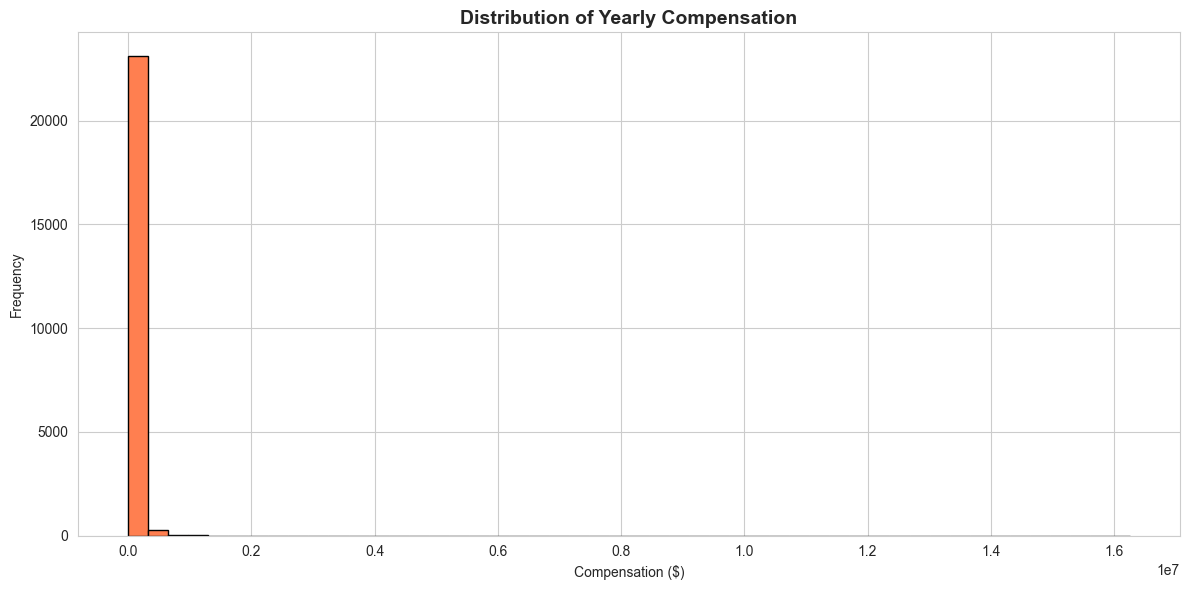

In [6]:
# Visualize compensation distribution
if comp_col:
    plt.figure(figsize=(12, 6))
    plt.hist(comp_data, bins=50, color='coral', edgecolor='black')
    plt.title('Distribution of Yearly Compensation', fontsize=14, fontweight='bold')
    plt.xlabel('Compensation ($)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## Detecting Outliers Using IQR Method

I'll use the Interquartile Range (IQR) method to identify outliers in the compensation data.

In [7]:
if comp_col:
    # Calculate IQR
    Q1 = comp_data.quantile(0.25)
    Q3 = comp_data.quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"Q1 (25th percentile): ${Q1:,.2f}")
    print(f"Q3 (75th percentile): ${Q3:,.2f}")
    print(f"IQR: ${IQR:,.2f}")
    
    # Calculate outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"\nOutlier boundaries:")
    print(f"Lower bound: ${lower_bound:,.2f}")
    print(f"Upper bound: ${upper_bound:,.2f}")
    
    # Identify outliers
    outliers = comp_data[(comp_data < lower_bound) | (comp_data > upper_bound)]
    print(f"\nNumber of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {(len(outliers) / len(comp_data) * 100):.2f}%")

Q1 (25th percentile): $32,712.00
Q3 (75th percentile): $107,971.50
IQR: $75,259.50

Outlier boundaries:
Lower bound: $-80,177.25
Upper bound: $220,860.75

Number of outliers: 978
Percentage of outliers: 4.17%


Let me visualize the outliers using a box plot.

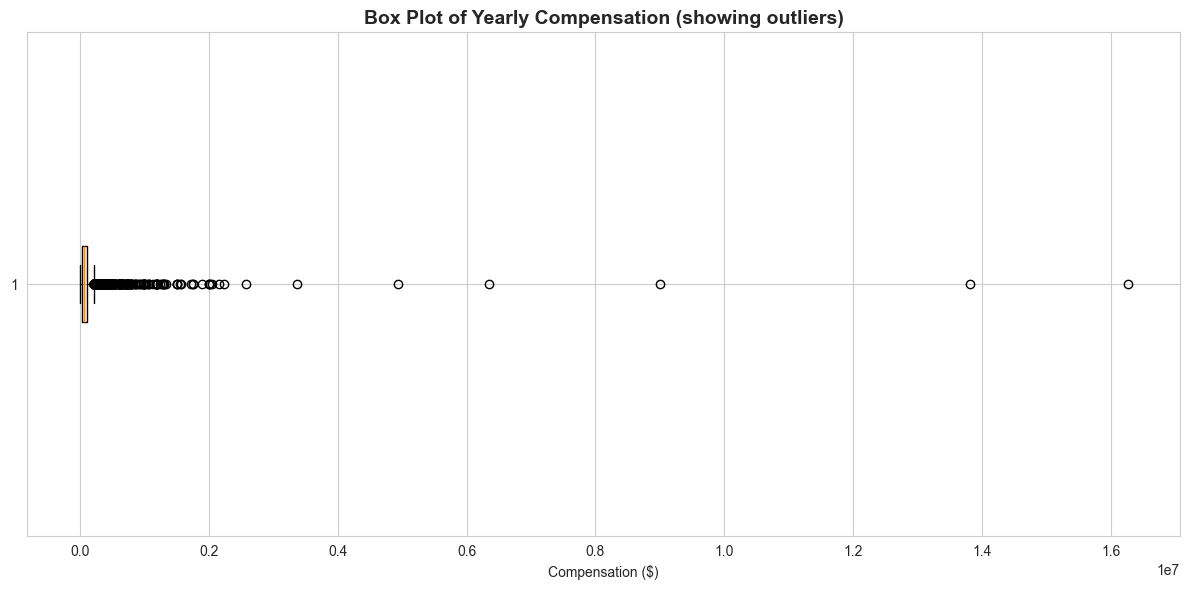

In [8]:
# Create box plot to visualize outliers
if comp_col:
    plt.figure(figsize=(12, 6))
    plt.boxplot(comp_data, vert=False)
    plt.title('Box Plot of Yearly Compensation (showing outliers)', fontsize=14, fontweight='bold')
    plt.xlabel('Compensation ($)')
    plt.tight_layout()
    plt.show()

## Removing Outliers

Now I'll create a new dataset without the outliers.

In [9]:
if comp_col:
    # Create a mask for non-outlier rows
    outlier_mask = (df[comp_col] >= lower_bound) & (df[comp_col] <= upper_bound)
    
    # Create new dataframe without outliers
    df_no_outliers = df[outlier_mask | df[comp_col].isna()].copy()
    
    print(f"Original dataset size: {df.shape[0]} rows")
    print(f"Dataset without outliers: {df_no_outliers.shape[0]} rows")
    print(f"Rows removed: {df.shape[0] - df_no_outliers.shape[0]}")

Original dataset size: 65437 rows
Dataset without outliers: 64459 rows
Rows removed: 978


In [10]:
# Compare statistics before and after removing outliers
if comp_col:
    comp_no_outliers = df_no_outliers[comp_col].dropna()
    
    print("Comparison of Statistics:")
    print("\nOriginal Data:")
    print(f"Mean: ${comp_data.mean():,.2f}")
    print(f"Median: ${comp_data.median():,.2f}")
    print(f"Std Dev: ${comp_data.std():,.2f}")
    
    print("\nData Without Outliers:")
    print(f"Mean: ${comp_no_outliers.mean():,.2f}")
    print(f"Median: ${comp_no_outliers.median():,.2f}")
    print(f"Std Dev: ${comp_no_outliers.std():,.2f}")

Comparison of Statistics:

Original Data:
Mean: $86,155.29
Median: $65,000.00
Std Dev: $186,756.97

Data Without Outliers:
Mean: $71,347.20
Median: $63,694.00
Std Dev: $51,271.40


## Visualizing Before and After

Let me compare the distributions before and after removing outliers.

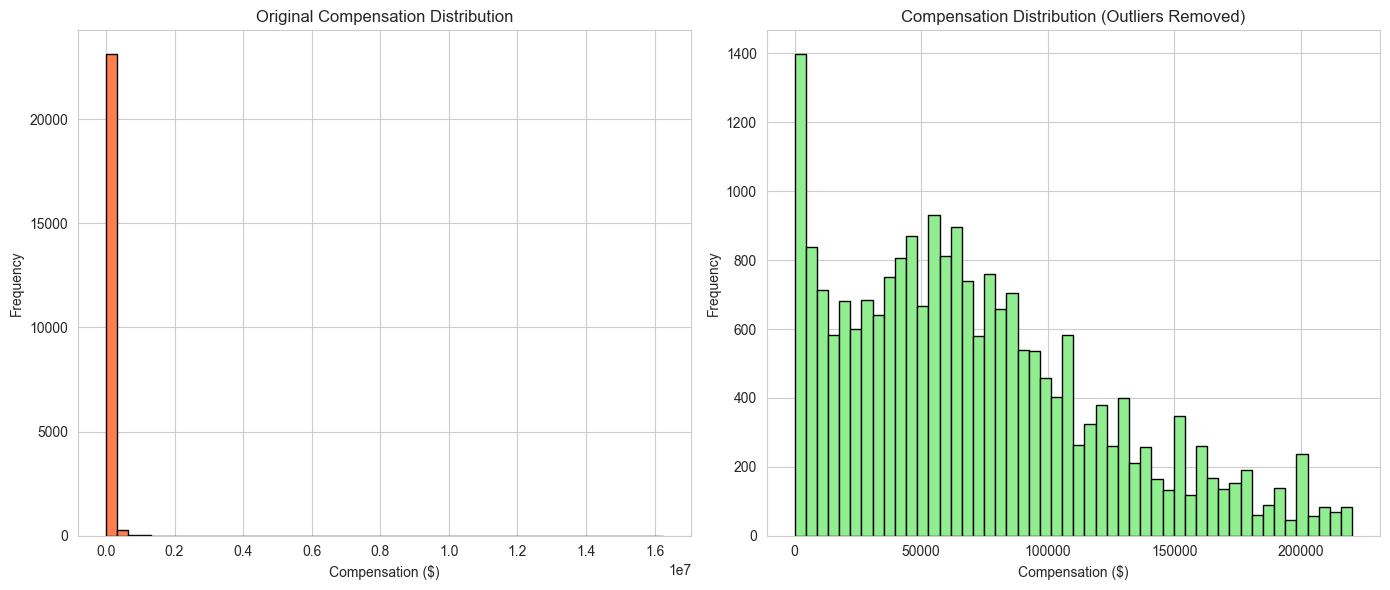

In [11]:
if comp_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Original distribution
    axes[0].hist(comp_data, bins=50, color='coral', edgecolor='black')
    axes[0].set_title('Original Compensation Distribution')
    axes[0].set_xlabel('Compensation ($)')
    axes[0].set_ylabel('Frequency')
    
    # Distribution without outliers
    axes[1].hist(comp_no_outliers, bins=50, color='lightgreen', edgecolor='black')
    axes[1].set_title('Compensation Distribution (Outliers Removed)')
    axes[1].set_xlabel('Compensation ($)')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

## Correlation Analysis

I'll analyze the correlation between Age and other numeric columns.

In [12]:
# Check if Age column exists
if 'Age' in df_no_outliers.columns:
    # Map age ranges to numeric values
    age_mapping = {
        'Under 18 years old': 17,
        '18-24 years old': 21,
        '25-34 years old': 29.5,
        '35-44 years old': 39.5,
        '45-54 years old': 49.5,
        '55-64 years old': 59.5,
        '65 years or older': 70,
        'Prefer not to say': None
    }
    
    # Create numeric age column
    df_no_outliers['Age_Numeric'] = df_no_outliers['Age'].map(age_mapping)
    
    print("Age mapping applied:")
    print(df_no_outliers[['Age', 'Age_Numeric']].drop_duplicates().dropna())
else:
    print("Age column not found")

Age mapping applied:
                   Age  Age_Numeric
0   Under 18 years old         17.0
1      35-44 years old         39.5
2      45-54 years old         49.5
3      18-24 years old         21.0
14     25-34 years old         29.5
23     55-64 years old         59.5
48   65 years or older         70.0


Correlation with Age:
Age_Numeric            1.000000
WorkExp                0.849536
ConvertedCompYearly    0.369685
JobSat                 0.068286
CompTotal             -0.002732
JobSatPoints_1        -0.029161
ResponseId            -0.031809
JobSatPoints_8        -0.045954
JobSatPoints_6        -0.049536
JobSatPoints_4        -0.075195
Name: Age_Numeric, dtype: float64


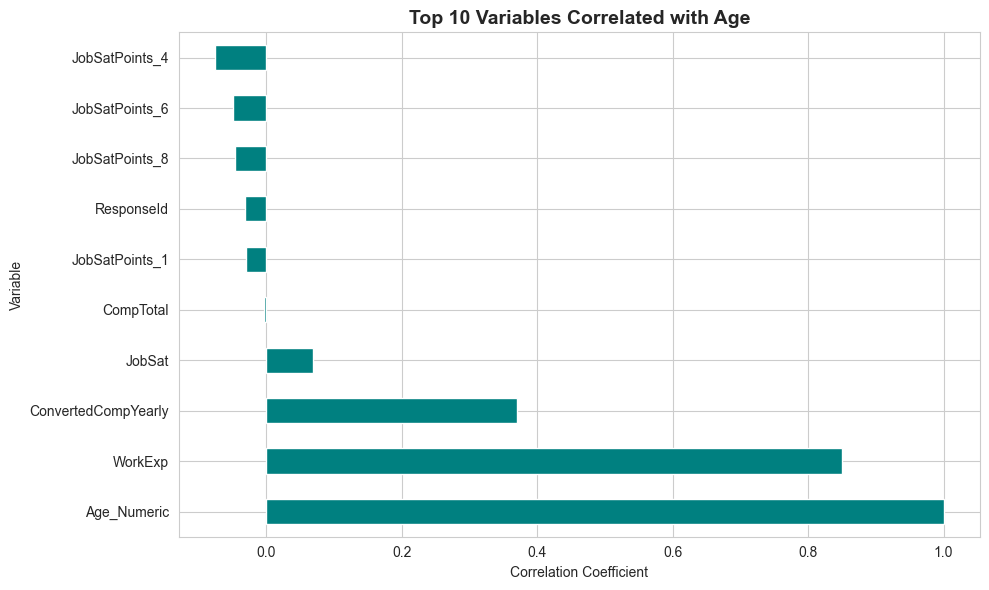

In [13]:
# Calculate correlations with Age
if 'Age_Numeric' in df_no_outliers.columns:
    # Select numeric columns
    numeric_cols = df_no_outliers.select_dtypes(include=[np.number]).columns.tolist()
    
    # Calculate correlation with Age_Numeric
    correlations = df_no_outliers[numeric_cols].corr()['Age_Numeric'].sort_values(ascending=False)
    
    print("Correlation with Age:")
    print(correlations.head(10))
    
    # Visualize top correlations
    plt.figure(figsize=(10, 6))
    correlations.head(10).plot(kind='barh', color='teal')
    plt.title('Top 10 Variables Correlated with Age', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()

## Correlation Heatmap

Let me create a heatmap to visualize correlations between key numeric variables.

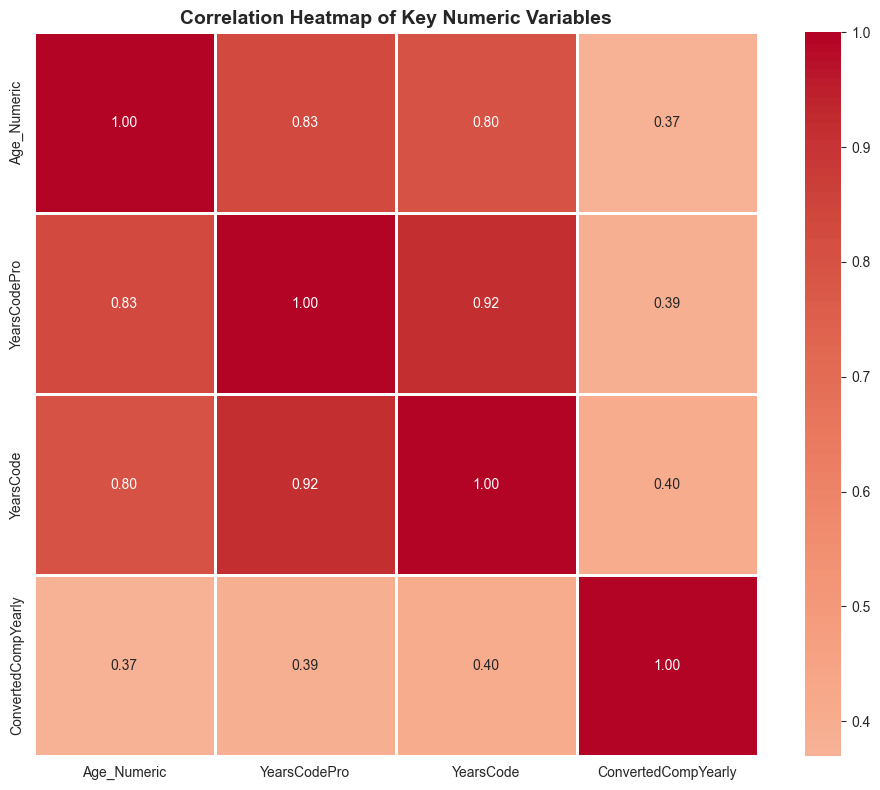

In [14]:
# Create correlation heatmap for key variables
if 'Age_Numeric' in df_no_outliers.columns:
    # Select a few key numeric columns
    key_cols = ['Age_Numeric']
    
    # Add other numeric columns if they exist
    for col in ['YearsCodePro', 'YearsCode', comp_col]:
        if col in df_no_outliers.columns:
            # Convert to numeric
            df_no_outliers[col] = pd.to_numeric(df_no_outliers[col], errors='coerce')
            key_cols.append(col)
    
    if len(key_cols) > 1:
        # Calculate correlation matrix
        corr_matrix = df_no_outliers[key_cols].corr()
        
        # Create heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                    square=True, linewidths=1, fmt='.2f')
        plt.title('Correlation Heatmap of Key Numeric Variables', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

## Saving the Cleaned Dataset

Finally, I'll save the dataset without outliers for future analysis.

In [15]:
# Save the cleaned dataset
df_no_outliers.to_csv('survey_data_no_outliers.csv', index=False)
print("✅ Dataset without outliers saved as 'survey_data_no_outliers.csv'")
print(f"Final dataset shape: {df_no_outliers.shape}")

✅ Dataset without outliers saved as 'survey_data_no_outliers.csv'
Final dataset shape: (64459, 115)


## Key Findings

Through this outlier analysis, I:

- **Explored industry distribution** to understand the survey's representation
- **Identified compensation outliers** using the IQR method
- **Removed extreme values** that could skew statistical analysis
- **Compared distributions** before and after outlier removal
- **Analyzed correlations** between age and other numeric variables
- **Created visualizations** to better understand the data patterns

Removing outliers helps create more reliable statistical models and ensures that extreme values don't distort our understanding of typical developer compensation and characteristics.